In [2]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
iris = load_iris()
X = iris.data
y = iris.target

### PART a)

In [3]:
pca = PCA(n_components=4)
pca.fit(X)

explained_variance = pca.explained_variance_ratio_
print("Explained variance by each component:", explained_variance)
print("Total variance explained (k = 4):", np.sum(explained_variance))

Explained variance by each component: [0.92461872 0.05306648 0.01710261 0.00521218]
Total variance explained (k = 4): 0.9999999999999999


#### The first Principal component explains 92.5% of the variation in the data. Each added component varies, by explaining less and less about the data. As K increases, the fraction of data it explains gets smaller.

## Part b)

##### Centering

In [9]:
X_centered = X - np.mean(X, axis=0)
pca = PCA(n_components=4)
pca.fit(X_centered)

explained_variance = pca.explained_variance_ratio_
print("Explained variance by each component on Centered data :", explained_variance)
print(f"Total variance explained (k = 4) on Centered Data: {np.sum(explained_variance):.4f}")

Explained variance by each component on Centered data : [0.92461872 0.05306648 0.01710261 0.00521218]
Total variance explained (k = 4) on Centered Data: 1.0000


There were no differences between the raw data and data that was centered. The variance each component explains is exactly the same, and the total variance is .0000000001 different. This is because PCA algorithm has centering built into it. So even though PCA technically centers the data around 0 by subtracting the mean of the raw data from the raw data, it remains the same.

##### Scaling Features

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_minmax.fit_transform(X)

pca = PCA(n_components=4)
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained variance by each component on Scaled data :", explained_variance)
print(f"Total variance explained (k = 4) on Scaled Data: {np.sum(explained_variance):.4f}")

Explained variance by each component on Scaled data : [0.84136038 0.11751808 0.03473561 0.00638592]
Total variance explained (k = 4) on Scaled Data: 1.0000


For scaling, the explained variance by each component is different from the raw data in the way that it is more evenly distributed. The Raw data has a heavy load of explained variance on the first component and not so much on the rest, but the scaled data has less on the first and is more evenly spread out. This is because Scaling spreads out variance in components. Scaling ensures that one singular feature isn't to heavily weighted/dominant.

##### Standardization

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)

pca = PCA(n_components=4)
pca.fit(X_standardized)

explained_variance = pca.explained_variance_ratio_
print("Explained variance by each component on Standardized data :", explained_variance)
print(f"Total variance explained (k = 4) on Standardized Data: {np.sum(explained_variance):.4f}")
print("Eigenvectors (principal components):", pca.components_)


Explained variance by each component on Standardized data : [0.72962445 0.22850762 0.03668922 0.00517871]
Total variance explained (k = 4) on Standardized Data: 1.0000
Eigenvectors (principal components): [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


In Standardization, the explained variance by each component is different from the raw data in the way that it is more evenly distributed, and it's even more evenly distributed then scaled data. The Raw data has a heavy load of explained variance on the first component and not so much on the rest, but the standardized data has less on the first and is more evenly spread out through all components. This is because Standardization takes a feature and subtracts its mean then divides by its standard deviation. THis helps ensure even more, that there are less features that completely dominate PCA.

##### Normalization

In [12]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')  # L2 norm = 1
X_normalized = normalizer.fit_transform(X)

pca = PCA(n_components=4)
pca.fit(X_normalized)

explained_variance = pca.explained_variance_ratio_
print("Explained variance by each component on Normalized data :", explained_variance)
print(f"Total variance explained (k = 4) on Normalized Data: {np.sum(explained_variance):.4f}")

Explained variance by each component on Normalized data : [0.962373   0.02758655 0.00818093 0.00185952]
Total variance explained (k = 4) on Normalized Data: 1.0000


In Normalization, the explained variance by each component is different from the raw data in the way that it is less evenly distributed. The Raw data has a heavy load of explained variance on the first component and not so much on the rest, and the Normalized data has even more weight on the first and is less evenly spread out through all components. This is because Normalization divides each feature by the Euclidean distance of the sample. This makes each sample have a length, and PCA relies on the one with the most dominant length which is the first component.

## Part c)

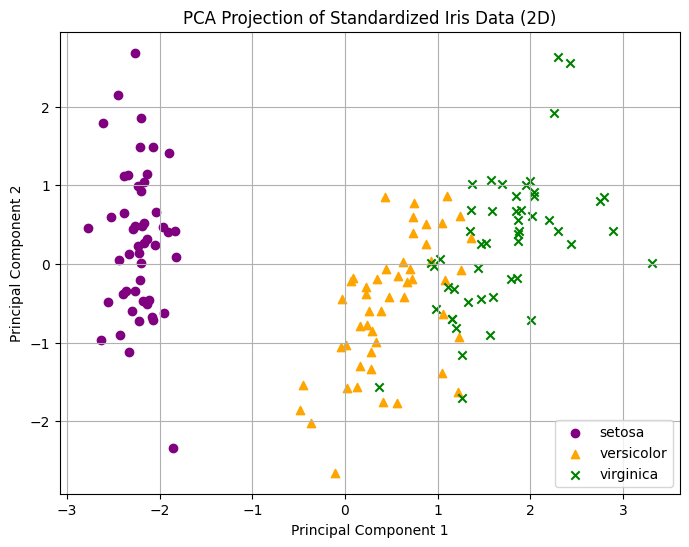

In [16]:
X_2 = StandardScaler().fit_transform(X)
# PCA on standardized data
pca = PCA(n_components=2)
X_pca2 = pca.fit_transform(X_2)


plt.figure(figsize=(8, 6))
colors = ['purple', 'orange', 'green']
markers = ['o', '^', 'x']
target_names = iris.target_names

for label in np.unique(y):
    plt.scatter(X_pca2[y == label, 0], X_pca2[y == label, 1],
                c=colors[label], marker=markers[label],
                label=target_names[label])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Standardized Iris Data (2D)")
plt.legend()
plt.grid(True)
plt.show()

There are three flower clusters.

## Part d)

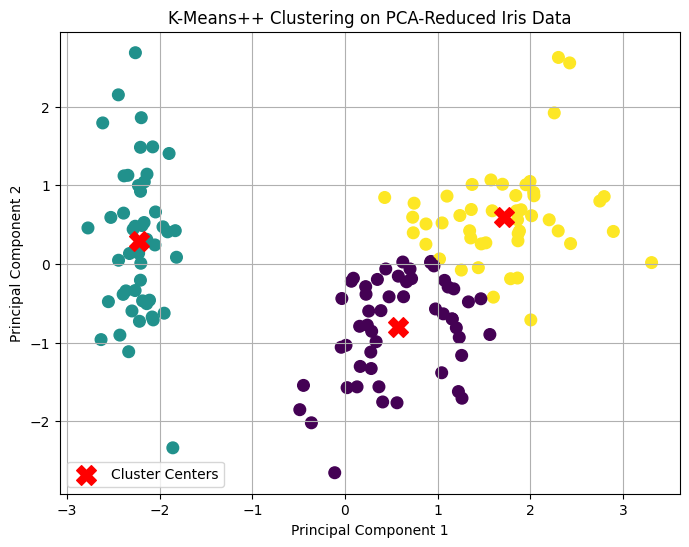

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca2)

# Plot clusters with cluster centers
plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=cluster_labels, s=70)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', s=200, marker='X', label='Cluster Centers')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means++ Clustering on PCA-Reduced (2D) Iris Data")
plt.legend()
plt.grid(True)
plt.show()

There are three seperate clusters. The one cluster is completely isolated on the left, while the two clusters on the right have some overlapping. This might mean that the flower species on the right are pretty similar in features, while the one on the left isn't similar to the two others. Each of the cluster centers are well positioned in the center of each group of data. This dataset is seperable, and there are clusters that seperate the data meaningfully. In this case each cluster represents a species of flower.